# Eikonal / Fast Marching Intuition

We propagate on the full domain and extract multiple geodesics.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

import heapq
import ipywidgets as widgets
n = 150
x = np.linspace(-1,1,n); y = np.linspace(-1,1,n)
X, Y = np.meshgrid(x, y)
cost = 1 + 2.8*np.exp(-((X-0.1)**2 + (Y+0.05)**2)/0.08) + 2.2*np.exp(-((X+0.2)**2 + (Y-0.2)**2)/0.06)
src = (n//2, n//2)
T = np.full((n,n), np.inf)
vis = np.zeros((n,n), bool)
par = np.full((n,n,2), -1, int)
pq = [(0.0, src[0], src[1])]
T[src] = 0.0
fronts = []
count = 0
marks = [1200, 3500, 7000, 11000]
while pq:
    d,i,j = heapq.heappop(pq)
    if vis[i,j]:
        continue
    vis[i,j] = True
    count += 1
    if count in marks:
        fronts.append(vis.copy())
    for di,dj in [(-1,0),(1,0),(0,-1),(0,1)]:
        ii,jj = i+di, j+dj
        if 0 <= ii < n and 0 <= jj < n and not vis[ii,jj]:
            nd = d + 0.5*(cost[i,j]+cost[ii,jj])
            if nd < T[ii,jj]:
                T[ii,jj]=nd
                par[ii,jj]=[i,j]
                heapq.heappush(pq,(nd,ii,jj))

targets = [(10,10), (20,n-20), (n-20,20), (n-15,n-15), (n//2,n-12)]
paths=[]
for dst in targets:
    p=[]; i,j=dst
    while (i,j)!=src and i>=0:
        p.append((i,j)); i,j = par[i,j]
    p.append(src)
    paths.append(np.array(p[::-1]))


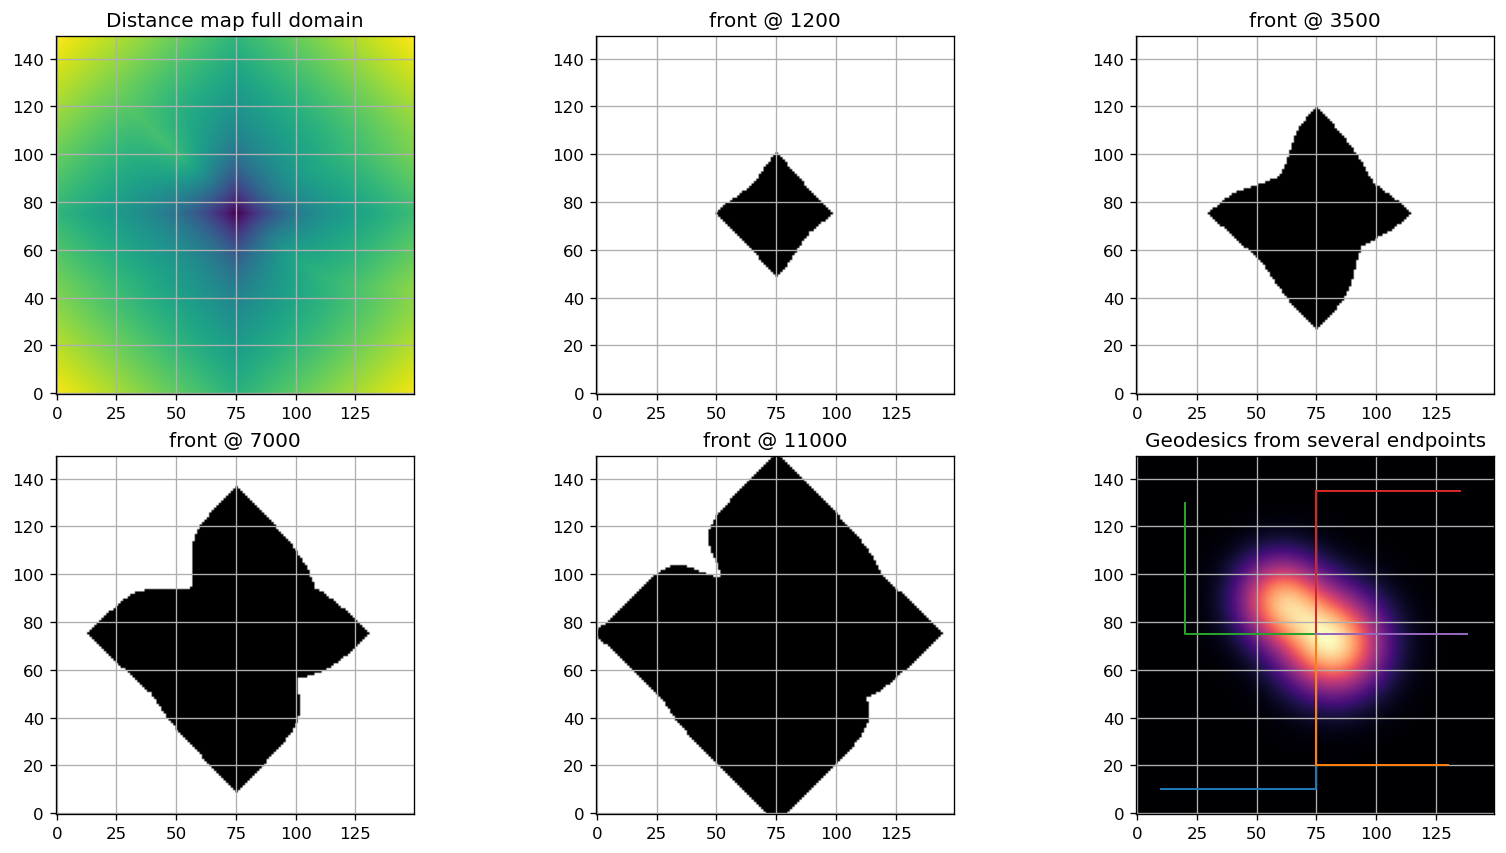

In [2]:
fig, axes = plt.subplots(2,3, figsize=(13.5,7), constrained_layout=True)
axes[0,0].imshow(T, origin='lower', cmap='viridis'); axes[0,0].set_title('Distance map full domain')
for ax, F, k in zip(axes.ravel()[1:5], fronts, marks):
    ax.imshow(F, origin='lower', cmap='gray_r')
    ax.set_title(f'front @ {k}')
axg = axes[1,2]
axg.imshow(cost, origin='lower', cmap='magma')
for p in paths:
    axg.plot(p[:,1], p[:,0], lw=1.2)
axg.set_title('Geodesics from several endpoints')
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Interactive front progression
